# Module 3: Supervised Machine Learning

---

## Learning Objectives

By the end of this module, you will be able to:

- Perform **exploratory data analysis** on a security dataset — distributions, outliers,
  correlations, class balance — and know which of those actually change your decisions.
- Use **correlation analysis to interrogate a feature set**, not just to prune it. You will
  find that this dataset's single strongest predictor is an artifact of how it was encoded.
- Explain the **accuracy trap** and why precision and recall matter more than accuracy on
  security data.
- Measure the real cost of the standard fixes for class imbalance — **SMOTE, undersampling
  and class weighting** — rather than assuming they help.
- **Tune a decision threshold**, and show that it beats all three of them.
- Diagnose **underfitting and overfitting** from learning curves.
- Build correct **scikit-learn pipelines**, and demonstrate what a leak costs: the same
  model reports an F1 of 0.95 or 0.11 depending on where you put one line.
- Compare several model families and pick one on evidence.

---

## Where we left off

In Module 2 you built a Logistic Regression classifier and learned that a perfect score is
a symptom rather than an achievement. The toy log's model scored 100% by discovering that
the firewall's own verdict was sitting in the feature set.

You also did something less obvious. You took the defects Module 1 found in the phishing URL
dataset, fixed them, trained a model — and measured that fixing them changed the score by
almost nothing.

This module is where that gets complicated in two directions.

**First**, you will find a defect in that same dataset that *does* matter — one that
correlation analysis exposes and that neither Module 1 nor Module 2 could see.

**Second**, you will meet a dataset where the class imbalance is genuinely severe, apply the
three standard textbook fixes, and discover that all three make the model measurably worse.
The thing that actually works is something else entirely.

---

###1. Visual Analysis: Exploratory Data Analysis (EDA)

Before we can fix our data or build better models, we have to learn to see it. In Module 2, we used simple commands like .head() and .info() to inspect our data. Now, we'll upgrade our toolkit to perform Exploratory Data Analysis (EDA), which is the practice of using visualizations to uncover the hidden stories, patterns, and problems within a dataset.

A single chart can often tell you more than a thousand rows of data. For a security analyst, visualizations are critical for answering questions like:

* What does "normal" behavior look like? (Understanding the baseline)

* Are there obvious outliers? (Visually spotting anomalies)

* Are my features related? (Finding redundant data)

* Is my dataset imbalanced? (Visually confirming the problem)



---

###2. Our Toolkit for Visual Analysis: Matplotlib and Seaborn

To perform the powerful Exploratory Data Analysis (EDA) we just discussed, we will use two specific Python libraries: Matplotlib and Seaborn. It's important to understand what each one does and how they work together.

1. **Matplotlib: The Foundation**

* What it is: Matplotlib is the original, foundational plotting library for Python. It is an incredibly powerful and flexible tool that gives you fine-grained control over every single element of your plot (like the axes, labels, and ticks).

* Its Role: Think of Matplotlib as the "engine." It can create any 2D plot you can imagine, but it can sometimes be complex and require a lot of code to make a plot look polished.

2. **Seaborn: The High-Level Interface**

* What it is: Seaborn is a more modern library that is built directly on top of Matplotlib. It's designed to make creating beautiful, complex, and statistically-aware visualizations much easier and more efficient.

* Its Role: Think of Seaborn as the "beautiful dashboard" that controls the Matplotlib engine. It excels at creating complex plots like heatmaps, box plots, and violin plots in a single line of code.

**How We Will Use Them**

We will use these two libraries together. We'll rely on Seaborn for most of our heavy lifting, as it allows us to create powerful statistical visualizations quickly. We will then use Matplotlib to make small adjustments and fine-tune our plots, such as adding a title or saving the image.

---

# Lab A: Interrogating a Feature Set

We return to the phishing URL dataset from Modules 1 and 2 — 88,647 URLs, each described by
111 numeric measurements.

You already know things about it. Module 1 found that `isnull()` reports zero missing values
while 66 columns encode missingness as `-1`, that there are 1,438 duplicate rows, 6
contradictory feature vectors, and 13 columns with no information at all. Module 2 dropped
the dead columns and the duplicates, trained a model, and reached 93.35% accuracy against a
65.03% baseline.

This lab asks the question neither of those answered: **what is that model actually using?**

In [1]:
# ============================================================
# Module 3 Setup -- run this cell first, every session.
# ============================================================
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

DATA_URL = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/"

print(f"pandas {pd.__version__} | numpy {np.__version__} | seed {SEED}")

pandas 3.0.5 | numpy 2.5.2 | seed 42


In [2]:
urls = pd.read_parquet(DATA_URL + "phishing_dataset1.parquet")

# Apply what Module 1 found and Module 2 acted on.
features_all = [col for col in urls.columns if col != 'phishing']
dead = [col for col in features_all if urls[col].nunique() <= 1]
urls = urls.drop(columns=dead).drop_duplicates().reset_index(drop=True)

print(f"after Module 1's cleanup: {urls.shape[0]:,} rows x {urls.shape[1]} columns")
print(f"  ({len(dead)} constant columns and the duplicate rows are gone)")
print(f"class balance: {urls['phishing'].mean()*100:.1f}% phishing")

after Module 1's cleanup: 87,209 rows x 99 columns
  (13 constant columns and the duplicate rows are gone)
class balance: 35.0% phishing


## Lab A.1 — Split first, then look

One rule before any analysis: **split the data before you study it.**

This feels excessive. You are only computing correlations — how could looking at a number
leak anything? The answer is that *you* are part of the pipeline. Every decision you make
after seeing the test data — which features to keep, which threshold to use, which model to
try — is a decision informed by data you promised not to use. That is leakage laundered
through a human, and it does not show up in any diagnostic.

So: split now, and do the rest of this lab on the training set only.

In [3]:
from sklearn.model_selection import train_test_split

X = urls.drop(columns='phishing')
y = urls['phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

train = pd.concat([X_train, y_train], axis=1)

print(f"train: {X_train.shape[0]:,} rows   test: {X_test.shape[0]:,} rows")
print(f"phishing rate -- train {y_train.mean():.4f}, test {y_test.mean():.4f}  (stratify keeps these equal)")

train: 69,767 rows   test: 17,442 rows
phishing rate -- train 0.3497, test 0.3497  (stratify keeps these equal)


## Lab A.2 — Which features track the label?

**Task A.2.** Compute the Pearson correlation of every feature with `phishing`, using the
**training set only**. Print the ten strongest positive and five strongest negative.

Then stop and look hard at the top of that list before reading on.

In [ ]:
# --- TASK A.2 ---
# Compute the Pearson correlation of every feature with 'phishing', using the TRAINING
# set only (the `train` DataFrame). Print the 10 strongest positive and 5 strongest negative.
#
# Then stop and look hard at the top of that list before reading on.

# YOUR CODE HERE

## Lab A.3 — Eight features, one number

Eight different columns correlate with the label at **0.744** — identical to three
decimal places, and within 0.0003 of each other.

That does not happen by accident. Identical correlations mean those columns carry identical
information, which means they are — for all practical purposes — the same column wearing
eight different names.

One of them is `qty_dollar_file`, which is supposed to count dollar signs in the filename
part of a URL.

**Task A.3.** Find out what that column actually contains. Print how many distinct values it
takes and what they are. Then do the same for two of its tied partners.

In [ ]:
# --- TASK A.3 ---
# For each of 'qty_dollar_file', 'qty_questionmark_file', 'qty_hashtag_file' and
# 'qty_at_file': print how many DISTINCT values the column takes, and what they are.
#
# Hint: .nunique() and .value_counts()

# YOUR CODE HERE

### What that column really is

`qty_dollar_file` takes exactly two values: `-1` and `0`. Never 1, never 2.

- `-1` means the URL has **no file part**, so there was nothing to count. That is Module 1's
  sentinel.
- `0` means the URL **does** have a file part, and it contains no dollar signs — which is
  true of essentially every URL, because dollar signs in filenames are rare.

A column sold as *"how many dollar signs are in the filename"* is in reality a **one-bit
flag**: does this URL have a file component at all?

**Task A.4.** Test that directly. Build a binary indicator — `1` when `qty_dollar_file` is
not `-1`, `0` otherwise — and check two things: its correlation with the label, and the
phishing rate on each side of it.

In [ ]:
# --- TASK A.4 ---
# 1. Build a binary indicator: 1 where qty_dollar_file is NOT -1, else 0.
# 2. Print its correlation with 'phishing', and the original column's, side by side.
# 3. Use pd.crosstab(..., normalize='index') to show the phishing rate on each side
#    of that indicator.

# YOUR CODE HERE

### Sit with that for a moment

The strongest predictor in a 111-feature phishing dataset is **whether the URL has a path**.

Not a suspicious keyword. Not an unusual character. Not the age of the domain. Just: is
there anything after the hostname?

Almost certainly, that is a fact about **how this dataset was collected**, not a fact about
phishing. Legitimate URLs were most likely gathered as bare domains — `example.com` — while
phishing URLs were captured as complete links to a landing page — `example.com/login/verify.php`.
The model that learns this is not detecting phishing. It is detecting which harvesting script
produced the row.

Deploy it against a real feed where both classes arrive as full URLs and the single feature
carrying most of its signal becomes constant.

This does not make Module 2's 93.35% a lie. The model really did score that. It makes the
number **mean something different** than it appeared to, and the only way to find that out
was to look at what the features contain rather than what they are named.

**Task A.5 — write-up.**

1. Explain in your own words why `qty_dollar_file` and `qty_hashtag_file` have identical
   correlations with the label.
2. Suppose you deployed Module 2's model on a live feed where every URL — phishing or not —
   arrives as a full path. What happens to its accuracy, and why?
3. You cannot re-collect this dataset. Name one thing you could do to the feature set to
   make a model trained on it less dependent on this artifact.
4. Module 1 found the `-1` sentinels and called them a data-quality problem. Module 3 has
   just shown they are also the strongest signal in the data. Are those two statements in
   conflict? Explain.

**[insert response]**

## Lab A.6 — Redundancy between features

Correlation with the *target* tells you which features carry signal. Correlation *between*
features tells you how much of that signal is duplicated.

**Task A.6.** Compute the correlation matrix over the training features, take the upper
triangle so each pair appears once, and report how many pairs exceed |r| ≥ 0.95. Print the
strongest few.

In [ ]:
# --- TASK A.6 ---
# Compute the absolute correlation matrix over the TRAINING features (no label).
# Take the upper triangle so each pair is counted once, then report how many pairs
# have |r| >= 0.95 and print the strongest few.
#
# Hint: np.triu(np.ones_like(matrix, dtype=bool), k=1) builds the mask;
#       .where(mask).unstack().dropna().sort_values(ascending=False) gives the pairs.

# YOUR CODE HERE

## Lab A.7 — Pruning by threshold

The standard remedy is to walk the correlated pairs and, from each, drop whichever feature
correlates *less* with the target — keeping the more informative of the two.

**Task A.7.** Write that procedure as a function of a threshold, and report how many features
survive at 0.95, 0.9, 0.8 and 0.7.

In [ ]:
# --- TASK A.7 ---
# Write a function prune(threshold) that walks the correlated pairs and, for each pair
# above the threshold, discards whichever feature has the WEAKER absolute correlation
# with the target. Return the set of surviving feature names.
#
# Report how many survive at 0.95, 0.9, 0.8 and 0.7, then keep the 0.9 set as `selected`.

# YOUR CODE HERE

---

# Lab B: The Accuracy Trap

## First, an honest look at the dataset you have been using

Before we leave the URL data, check its class balance.

phishing
0    56712
1    30497

phishing: 35.0%   legitimate: 65.0%


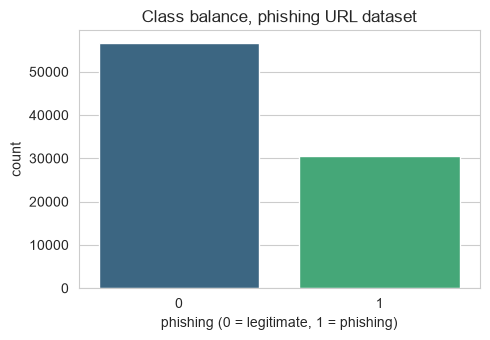

In [9]:
counts = urls['phishing'].value_counts()
print(counts.to_string())
print(f"\nphishing: {counts[1]/len(urls)*100:.1f}%   legitimate: {counts[0]/len(urls)*100:.1f}%")

plt.figure(figsize=(5, 3.5))
sns.countplot(x='phishing', data=urls, hue='phishing', palette='viridis', legend=False)
plt.title('Class balance, phishing URL dataset')
plt.xlabel('phishing (0 = legitimate, 1 = phishing)')
plt.tight_layout(); plt.show()

**About 35% phishing.** That is mildly unbalanced and nothing more. Module 2's model
reached 91% recall on the minority class without any special handling at all.

This matters because a great deal of security-ML teaching — including earlier versions of
this module — asserts that your data is *severely* imbalanced and that you must therefore
apply resampling. On this dataset that claim is simply false, and applying the standard
fixes to it would be solving a problem you do not have.

So for the rest of this module we switch to a dataset where the problem is real.

---

## The credit card fraud dataset

284,807 real transactions. **492 of them are fraudulent** — 0.17%.

That is a ratio of roughly 578 to 1, and it is representative of genuine detection problems:
intrusions, malware detonations, account takeovers. The rare thing is the thing you care
about.

### 10. A Deep Dive on Model Metrics: Why Accuracy is a Trap

The countplot you are about to draw for the fraud data shows what severe imbalance actually
looks like: one bar so tall the other is invisible.

This isn't just a "data problem"; it's the #1 reason that new data scientists build useless security models.

**The Accuracy Trap**

Imagine a dataset with 10,000 log entries, where 9,900 are "Benign" and 100 are "Attacks." A machine learning model is lazy. It can achieve 99% accuracy by learning a very simple, stupid rule:

*Always predict 'Benign'*.

* The model is technically "correct" 99% of the time, but it has learned nothing about how to spot a threat. It has completely failed its one real job. This is the Accuracy Trap.

* To get out of this trap, we have to stop using "Accuracy" as our main metric and start using a more sophisticated "magnifying glass" that tells us where our model is making mistakes.

**The Magnifying Glass: The Confusion Matrix**

A Confusion Matrix is the single best tool for understanding a classifier's performance. It's a simple grid that breaks down all of our test predictions into four categories:

* True Positive (TP): The model predicted "Phishing," and the URL was "Phishing." (A successful catch!)

* True Negative (TN): The model predicted "Benign," and the URL was "Benign." (A correct rejection.)

* False Positive (FP) (Type I Error): The model predicted "Phishing," but the URL was "Benign." (A false alarm. This annoys users or analysts.)

* False Negative (FN) (Type II Error): The model predicted "Benign," but the URL was "Phishing." (A catastrophic failure. The attack gets through.)

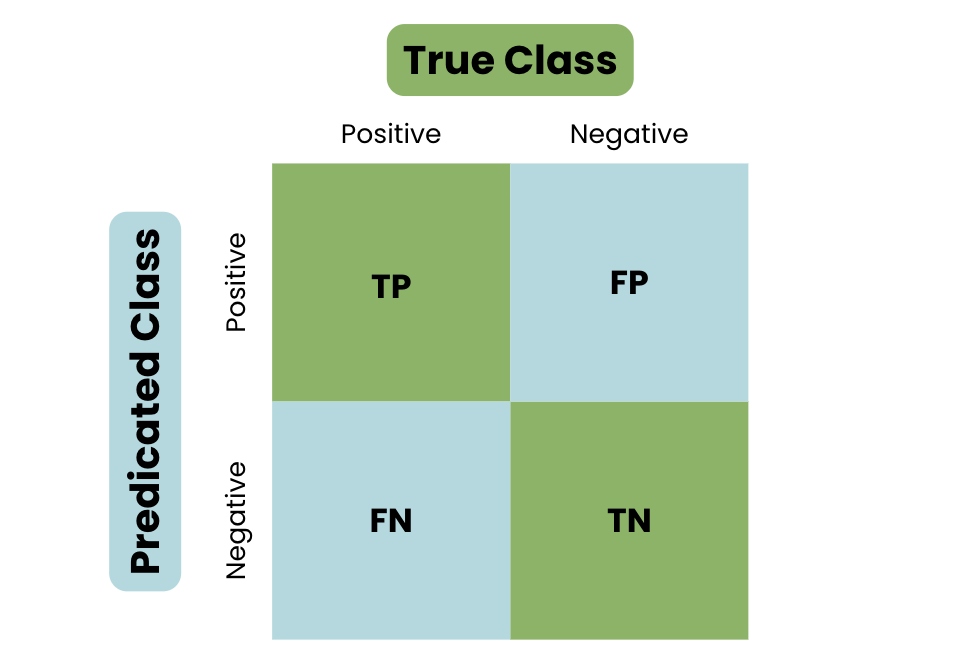

**The Key Metrics: Precision, Recall, and F1-Score**

From these four numbers, we get the three most important metrics for classification.

**Precision: The "False Alarm" Metric**

Question: "Of all the alerts the model generated, how many were actually malicious?"

Formula: ```TP / (TP + FP)```

Why it Matters: High precision means your model is trustworthy. When it flags something, your analysts know it's worth investigating. Low precision means the model is "the boy who cried wolf," flooding your team with false positives until they start ignoring its alerts completely.

**Recall: The "Catch Rate" Metric**

Question: "Of all the real attacks that happened, how many did our model catch?"

Formula: ```TP / (TP + FN)```

Why it Matters: High recall means your model is effective at its job. It's finding the needles in the haystack. Low recall means your model is letting threats slip through the net, which is the worst possible outcome.

**F1-Score: The "Balanced" Metric**

Question: "How can I get a single score that balances the trade-off between Precision and Recall?"

Formula: ```2 * (Precision * Recall) / (Precision + Recall)```

**Why it Matters:** The F1-Score is the harmonic mean of Precision and Recall. It gives you a single, combined score. More importantly, it severely punishes models that are extremely one-sided. A model with 100% Precision but 1% Recall will have a terrible F1-Score, which correctly tells you it's a useless model.

**The Advanced Metric: ROC-AUC**

Finally, there is one more advanced metric that is critical for comparing models: the ROC-AUC Score.

* ROC (Receiver Operating Characteristic) Curve: This is a graph that plots the True Positive Rate (Recall) against the False Positive Rate at every possible threshold. A model that is a perfect classifier would have a curve that goes straight up the left side and across the top.

* AUC (Area Under the Curve): This is the metric we care about. It calculates the entire area under that ROC curve and gives you a single score between 0.5 and 1.0.

**1.0: A perfect model that can perfectly distinguish between the two classes.**

**0.5: A useless model that is no better than random guessing.**

The AUC score is the single best measure of a model's overall ability to distinguish between "Phishing" and "Benign".

**The Analyst's Dilemma: The Trade-Off**

You will almost never have 100% Precision and 100% Recall. There is always a trade-off.

* To get 100% Recall, you could build a model that flags everything as "suspicious." You'd catch every threat, but your Precision would be 1%, and your analyst team would quit.

* To get 100% Precision, you could build a model that only flags an attack it is 100.00% sure about. Your alerts would be perfect, but your Recall would be 5%, and you'd miss all the new, subtle attacks.

The "right" balance depends on the business. For a spam filter, you might favor Precision (don't flag a legitimate email as spam). For detecting ransomware, you must favor Recall (you're willing to accept a few false alarms to avoid a catastrophic breach).


## Lab B.1 — Load it and look

**Task B.1.** Load `creditcard.csv.zip`, report the class balance in both counts and
percentages, and draw the countplot. Compare it with the URL plot above.

In [ ]:
# --- TASK B.1 ---
# Load creditcard.csv.zip from DATA_URL (it needs compression='zip').
# Report the row count, the class counts, the fraud percentage and the ratio.
# Then draw a countplot of the 'Class' column.

# YOUR CODE HERE

## Lab B.2 — Train the obvious model

**Task B.2.** Split 80/20 stratified, scale (fitting on train only), train a
`LogisticRegression`, and print the full classification report.

Before you run it, write down what accuracy you expect.

In [ ]:
# --- TASK B.2 ---
# 1. Split 80/20, stratified on 'Class', random_state=SEED.
# 2. Scale with StandardScaler -- fit on TRAIN only.
# 3. Train LogisticRegression(max_iter=2000).
# 4. Print classification_report with target_names=['normal','fraud'] and digits=3,
#    plus the confusion matrix.
#
# Name your results Xf_tr, Xf_te, yf_tr, yf_te, Xf_tr_s, Xf_te_s, naive, naive_pred
# so the later cells work.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# YOUR CODE HERE

### Read that carefully

**Accuracy: 99.914%.** By any ordinary standard that is an outstanding model.

**Recall on fraud: 0.633.** It misses more than a third of all fraudulent transactions.

Both are true at once, and the reason is arithmetic: 99.83% of the test set is normal, so a
model that got *every single fraud wrong* would still score 99.83% accuracy. The entire
interesting part of this problem lives inside the 0.17% that accuracy cannot see.

This is the accuracy trap, and it is not a hypothetical. It is the default outcome of doing
the obvious thing on a realistic security dataset.

**Task B.3 — write-up.**

1. Compute the accuracy of a model that always predicts "normal". How much did the trained
   model improve on it?
2. The bank's fraud team can investigate about 50 alerts a day. Given the precision and
   recall above, is this model deployable? Show your reasoning with numbers.
3. Which is worse for a bank, a false positive or a false negative? Now answer the same
   question for a hospital's ransomware detector, and explain why the answers differ.

**[insert response]**

---

# Lab C: The Standard Fixes, Measured

Open any textbook on imbalanced classification and you will find three remedies:

1. **Oversample the minority** — SMOTE generates synthetic minority examples by interpolating
   between real ones.
2. **Undersample the majority** — throw away normal examples until the classes match.
3. **Weight the classes** — tell the model that a mistake on the rare class costs more.

All three rebalance the training data. All three are widely taught, including by an earlier
version of this module, which presented SMOTE and undersampling as *the* fix.

We are going to apply all three and measure what they do. Take a moment first to predict the
outcome, because the result is not what almost anyone expects.

### One rule that is not optional

Whatever you resample, you resample **the training set only, after the split**.

SMOTE builds new minority points by interpolating between existing minority points. If you
run it before splitting, those synthetic points are derived from rows that then land on both
sides of the split. Your test set fills with near-copies of your training data, and your
score measures memorisation.

You will measure exactly how much that costs at the end of this lab.

## Lab C.1 — Apply all three

**Task C.1.** Train four models on the fraud data and report precision, recall and F1 for
the fraud class:

1. the naive model from Lab B (no rebalancing)
2. SMOTE applied to the scaled training set
3. random undersampling of the training set
4. `class_weight='balanced'` on the classifier

Test all four on the same untouched test set.

In [ ]:
# --- TASK C.1 ---
# Train four models and report fraud-class precision, recall and F1 for each,
# all evaluated on the SAME untouched test set:
#   1. the naive model from Lab B
#   2. SMOTE applied to the scaled training data
#   3. RandomUnderSampler applied to the scaled training data
#   4. LogisticRegression(class_weight='balanced') on the untouched training data
#
# A small helper that prints one formatted row keeps this readable.
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# YOUR CODE HERE

### What just happened

All three fixes did exactly what they promise: recall went from **0.633 to 0.918**. The model
now catches almost every fraud.

And all three destroyed the model. Precision fell from **0.827 to about 0.06**, taking F1 from
**0.717 down to roughly 0.10** — six times worse than doing nothing.

At 0.058 precision, the model raises about **16 false alarms for every real fraud it finds**.
Applied to this test set that is roughly 1,460 alerts. The fraud team can process 50.

Nothing here is a bug, and the textbooks are not wrong about what SMOTE does. The error is in
treating rebalancing as free. **What these methods actually do is move the model's operating
point** — they make it far more willing to shout "fraud". They just move it a very long way,
without asking you where you wanted it.

There is a way to move that same dial deliberately.

## Lab C.2 — Move the dial on purpose

A classifier does not really output a class. It outputs a **probability**, and something then
applies a cutoff — by default 0.5 — to turn it into a decision.

That 0.5 is a default, not a law. It is the one number in this entire pipeline that you can
change without retraining anything.

**Task C.2.** Take the naive model from Lab B — untouched, no rebalancing. Get its predicted
probabilities, sweep the threshold with a precision-recall curve, pick the cutoff that
maximises F1, and report the result next to the four models above.

In [ ]:
# --- TASK C.2 ---
# Take the NAIVE model -- no rebalancing, already trained.
# 1. Get predicted probabilities for the test set with .predict_proba(...)[:, 1].
# 2. Use precision_recall_curve to sweep the threshold.
# 3. Find the threshold maximising F1, and report the result against the default 0.5.
# 4. Plot precision and recall against threshold, marking your chosen point.
from sklearn.metrics import precision_recall_curve

# YOUR CODE HERE

## Lab C.3 — What a leak costs

Everything so far resampled **after** the split. Now measure what happens if you do it before.

**Task C.3.** Scale the whole dataset, apply SMOTE to all of it, *then* split, train and
evaluate. Compare the F1 with the correct version — and look carefully at the size and
composition of the test set you end up with.

In [ ]:
# --- TASK C.3 ---
# Do it WRONG on purpose, and measure the cost:
#   1. Scale the WHOLE dataset.
#   2. Apply SMOTE to all of it.
#   3. THEN split into train and test.
#   4. Train and evaluate.
#
# Print the leaky F1 next to the correct one, then print the size and fraud rate of
# both test sets. The second comparison matters more than the first.

# YOUR CODE HERE

### The scoreboard

| approach | precision | recall | **F1** |
|---|---|---|---|
| naive logistic regression | 0.827 | 0.633 | **0.717** |
| + SMOTE | 0.058 | 0.918 | **0.109** |
| + random undersampling | 0.038 | 0.918 | **0.074** |
| + `class_weight='balanced'` | 0.061 | 0.918 | **0.114** |
| **naive + tuned threshold** | 0.735 | 0.765 | **0.750** |
| *SMOTE before the split (leaky)* | *0.974* | *0.924* | *0.948* |

The best honest result comes from the model that got no special treatment at all, with one
number changed afterwards. The best-looking result is a fiction computed on a test set that
describes a world where half of all transactions are fraud.

**Task C.3 — write-up.**

1. What did you predict SMOTE would do before you ran Lab C.1, and where did that expectation
   come from?
2. All three rebalancing methods produced *exactly* the same recall, 0.918. Why would three
   different techniques land on an identical number?
3. Your fraud team can process 50 alerts per day. Using the precision-recall curve from
   Lab C.2, describe how you would choose a threshold from that constraint rather than by
   maximising F1.
4. The leaky run scored 0.948. Suppose a colleague reports that number to you. What single
   question would most quickly reveal the problem?

**[insert response]**

---

# Lab D: Underfitting, Overfitting, and Choosing a Model



## Common Issues: Underfitting and Overfitting

As we build and train machine learning models, two common pitfalls we must be aware of are underfitting and overfitting. These concepts describe how well our model generalizes to new, unseen data, which is crucial for real-world application.

#### Underfitting

**What it is:** Underfitting occurs when a model is too simple to capture the underlying patterns in the training data. It fails to learn from the training data effectively, resulting in poor performance on both the training data and new data.

**Symptoms:**
*   Low accuracy/F1-score on the training data.
*   Low accuracy/F1-score on the test data.
*   The model is too simplistic (e.g., a linear model trying to fit complex non-linear relationships).

**Causes:**
*   Model is too simple (e.g., not enough features, low model complexity).
*   Insufficient training time or an overly aggressive regularization (though this is more common with overfitting).

**Solutions:**
*   Increase model complexity (e.g., use more features, choose a more complex algorithm like a Random Forest instead of Logistic Regression).
*   Reduce regularization.
*   Add more relevant features to the dataset.

#### Overfitting

**What it is:** Overfitting occurs when a model learns the training data too well, including its noise and random fluctuations. It essentially memorizes the training data rather than learning generalizable patterns. As a result, it performs exceptionally well on the training data but poorly on new, unseen data.

**Symptoms:**
*   Very high accuracy/F1-score on the training data.
*   Significantly lower accuracy/F1-score on the test data.
*   The model is overly complex and captures noise as if it were a pattern.

**Causes:**
*   Model is too complex (e.g., too many features, very deep decision trees).
*   Not enough training data to represent the underlying patterns adequately.
*   Lack of regularization.

**Solutions:**
*   Simplify the model (e.g., reduce the number of features, use simpler algorithms, prune decision trees).
*   Increase the amount of training data.
*   Use regularization techniques (e.g., L1 or L2 regularization in linear models, setting `max_depth` for decision trees, `n_estimators` for Random Forests, or C-parameter for SVMs).
*   Use cross-validation to get a more robust estimate of model performance.
*   Apply feature selection techniques (as we did with correlation thresholds) to remove redundant or irrelevant features.

## Lab D.1 — Learning curves

A **learning curve** plots performance against the amount of training data used, for both the
training set and a held-out validation fold. The *shape* diagnoses the problem:

- **Underfitting** — both curves are low and close together. More data will not help; the
  model is not capable enough.
- **Overfitting** — the training curve is high, the validation curve is well below it, and the
  gap does not close. The model is memorising.
- **Healthy** — both are high, converging, with a small gap.

**Task D.1.** Build learning curves for two decision trees on the fraud training data: one
with `max_depth=2` and one with no depth limit. Score with F1 and use 3-fold cross-validation.
Predict which will underfit and which will overfit before you look.

In [ ]:
# --- TASK D.1 ---
# Build learning curves for two decision trees on the fraud training data:
# one with max_depth=2, one with max_depth=None. Score with 'f1', cv=StratifiedKFold(3),
# train_sizes=np.linspace(0.1, 1.0, 5). Plot training and validation F1 side by side.
#
# Predict which will underfit and which will overfit BEFORE you look.
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

##⚠️ CRITICAL WARNING: Do Not Manually Scale!

**Read this before running the final test.**

In previous labs, you might have manually scaled your data like this:

Python
**THE OLD WAY (Do NOT do this now)**
```python
X_test_scaled = scaler.transform(X_test)
model.predict(X_test_scaled)
```
However, we are now using Pipelines. Our best_estimator_ pipeline contains the scaler inside it. When you call .predict(X_test), the pipeline automatically scales the data for you.

If you pass raw data: The pipeline scales it → Correct Result.

If you pass scaled data: The pipeline scales it again (Double Scaling) → Incorrect Result.

Rule: Pass the original, unscaled X_test into the pipeline

###Deep Dive: How the Pipeline "Thinks"

A Pipeline is not just a list of steps; it is a smart workflow manager that knows the difference between Training (Learning) and Testing (Applying).

It changes its behavior based on which command you call.

**Scenario A: The Training Phase (.fit())**

Goal: Learn patterns, normalize data, and fix imbalance.

When we call grid_search.fit(X_train, y_train), the data flows through the pipeline like this:

1. Step 1: The Scaler (fit_transform)

* The Scaler looks at the training data, calculates the Mean and Standard Deviation, and transforms the data to be "standard."

* Result: Scaled Training Data.

2. Step 2: SMOTE (fit_resample)

* The Critical Step: SMOTE looks at the minority class and generates synthetic (fake) examples to balance the dataset.

* Result: A larger, perfectly balanced, scaled dataset.

3. Step 3: The Model (fit)

* The model (e.g., Random Forest) trains on this balanced, scaled data. It learns to recognize the minority class because SMOTE gave it enough examples to study.

**Scenario B: The Prediction Phase (.predict())**

Goal: Apply what we learned to real-world data.

When we call best_estimator_.predict(X_test), the pipeline changes its path. It knows that X_test is real data that we must not tamper with.

1. Step 1: The Scaler (transform)

* Crucial Difference: It does not calculate a new Mean/Std Dev. It uses the "Training Mean" it learned in Scenario A.

* Result: Test data that is scaled exactly like the training data.

2. Step 2: SMOTE (SKIPPED!)

* The Smart Switch: The pipeline bypasses SMOTE entirely. We do not want to generate fake data for the test set. We want to know how the model performs on real, imbalanced data.

3. Step 3: The Model (predict)

* The model takes the scaled (but not SMOTEd) test data and outputs a prediction.

Why is this important?

* If you didn't use a pipeline and tried to do this manually, you would have to write complex if/else logic to ensure you didn't accidentally SMOTE your test set or re-fit your Scaler.

## Lab D.2 — The bake-off

Now compare model families properly. Every model goes inside a `Pipeline` so that scaling is
fitted on each training fold and never touches the test data.

**Task D.2.** Train Logistic Regression, a depth-limited Decision Tree, and a Random Forest.
For each, report accuracy, precision, recall and F1 at the default threshold, then again at
its own tuned threshold. Also record training time.

In [ ]:
# --- TASK D.2 ---
# Put each model inside a Pipeline with StandardScaler, then for each one report:
# training time, accuracy, precision, recall, F1 at the default threshold, and F1 at
# its own tuned threshold.
#
#   Logistic Regression: LogisticRegression(max_iter=2000, random_state=SEED)
#   Decision Tree:       DecisionTreeClassifier(max_depth=6, random_state=SEED)
#   Random Forest:       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
#
# Remember: pass the RAW X_test to the pipeline, never the pre-scaled version.
import time
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE

**Task D.2 — write-up.**

1. Random Forest with no resampling at all scored F1 0.874. Logistic Regression with SMOTE
   scored 0.109. What does that tell you about where effort is best spent on an imbalanced
   problem?
2. Threshold tuning improved every model. Which benefited most, and why might that be?
3. Random Forest's best threshold was near 0.5 while Logistic Regression's was near 0.15.
   What does that difference say about the two models' output probabilities?
4. Random Forest took roughly 40× as long to train as Logistic Regression. Describe a
   situation in which you would deploy the slower, better model, and one in which you would not.

**[insert response]**

---

## Module 3 Summary

**Lab A — you interrogated a feature set and found something the previous two modules missed.**
Eight features tied at exactly 0.744 correlation with the label, because the `-1` sentinels
Module 1 discovered had collapsed thirty-four columns into what is effectively a single bit:
*does this URL have a path?* That bit is the strongest predictor in the dataset — 98.4% of
URLs without a path are legitimate, 72.8% of those with one are phishing — and it is almost
certainly an artifact of how the two classes were harvested rather than a property of
phishing.

**Lab B — you met the accuracy trap for real.** 99.914% accuracy, 0.633 recall. A model that
misses over a third of all fraud while scoring within a rounding error of perfect.

**Lab C — you measured the standard fixes and they failed.**

| approach | precision | recall | **F1** |
|---|---|---|---|
| naive | 0.827 | 0.633 | **0.717** |
| SMOTE | 0.058 | 0.918 | **0.109** |
| undersampling | 0.038 | 0.918 | **0.074** |
| class weighting | 0.061 | 0.918 | **0.114** |
| **naive + tuned threshold** | 0.735 | 0.765 | **0.750** |

All three textbook remedies raised recall and destroyed precision. Changing one number — the
decision threshold — beat every one of them, on the same model, without retraining.

**And you measured what a leak costs.** SMOTE before the split reports F1 **0.948** against an
honest **0.109**. The tell is not the score, it is the test set: 113,726 rows at 50% fraud, in
a problem that is 0.17% fraud, and larger than the dataset it came from.

**Lab D — you found what actually works.** Random Forest, with no resampling at all, reached
F1 **0.874**. Eight times better than logistic regression plus SMOTE. Choosing a better model
family beat the entire rebalancing toolkit.

### The thread through all three modules

Module 2 ended with two defects that cost nothing. Module 3 shows one that costs everything.
Both are true, and neither could be known in advance.

That is the habit this course is building: **when someone tells you a fix is necessary, or that
a defect is harmless, ask what they measured.** Usually the answer is nothing.

---

## Reflection Questions

**1.** Lab A found that the strongest feature in the phishing dataset encodes how the data was
collected rather than what phishing looks like. Describe how you would design a URL dataset
that does not have this problem.

**[insert response]**

**2.** Every rebalancing method landed on identical recall (0.918) and terrible precision.
Explain what those three methods have in common that produces that outcome.

**[insert response]**

**3.** You are handed a fraud model reporting F1 0.95. List the three questions you would ask,
in order, and say what answer to each would worry you.

**[insert response]**

**4.** Threshold tuning is nearly free and beat every resampling method here. Why do you think
resampling is taught so much more often?

**[insert response]**

**5.** Random Forest won without any imbalance handling. Does that mean class imbalance is not
a real problem? Defend your answer using numbers from this module.

**[insert response]**

---

##Sources:

* https://www.geeksforgeeks.org/python/how-to-make-histograms-with-density-plots-with-seaborn-histplot/

* https://medium.com/image-processing-with-python/theoretical-basis-of-ml-model-evaluation-metrics-summary-3cae19129679

* Learning material provided by Dr. ismail.

* Valuble insight and guidence provided by Maraz Mia.

* https://neptune.ai/blog/building-ml-model-training-pipeline